<a href="https://colab.research.google.com/github/SheethHassan/AI-Based-Pneumonia-Detection/blob/ML-MODEL/Pneumonia_Detection_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#PYTHON LIBRARIES
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, callbacks, applications, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score,
    roc_curve, auc, precision_recall_curve, matthews_corrcoef
)
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── COPY DATASET TO LOCAL SSD FOR FAST I/O ──────────────────────────────────
# Google Drive reads are slow (~19s/step). Copying to Colab's local SSD
# brings this down to ~1-2s/step, reducing total training from 10+ hours
# to 1-2 hours. This copy only takes 3-5 minutes and is worth it.

import shutil, os

src  = '/content/drive/MyDrive/chest_xray/chest_xray'
dst  = '/content/chest_xray'

if not os.path.exists(dst):
    print("Copying dataset from Drive to local SSD...")
    shutil.copytree(src, dst)
    print("Done! Dataset is now on local SSD.")
else:
    print("Dataset already on local SSD, skipping copy.")

Dataset already on local SSD, skipping copy.


In [ ]:
#Verifying Folder Structure

import os
for split in ['train', 'val', 'test']:
  for cls in ['NORMAL', 'PNEUMONIA']:
    path = f'/content/drive/MyDrive/chest_xray/chest_xray/{split}/{cls}'
    count = len(os.listdir(path))
    print(f"{split}/{cls}: {count} images")

train/NORMAL: 1342 images
train/PNEUMONIA: 3876 images
val/NORMAL: 9 images
val/PNEUMONIA: 9 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


In [ ]:
#Constants

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
INPUT_SHAPE = (224, 224, 3)
SEED = 42
FINAL_THRESHOLD = 0.3

In [ ]:
# Paths and Generators
# FIX: Validation data now uses a SEPARATE datagen WITHOUT augmentation.
# Using the training datagen for validation was causing data leakage —
# the validation images were being randomly rotated/zoomed, making
# validation metrics unreliable.

base_dir = '/content/chest_xray'   # local SSD — fast I/O
train_dir = f'{base_dir}/train'
test_dir  = f'{base_dir}/test'

# AUGMENTATION ONLY FOR TRAINING DATA
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    shear_range       = 0.15,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    brightness_range  = [0.8, 1.2],
    fill_mode         = "nearest",
    validation_split  = 0.20
)

# FIX: Separate datagen for validation — rescale only, NO augmentation
val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.20
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    subset      = 'training',
    seed        = SEED,
    shuffle     = True,
)

# FIX: Use val_datagen (no augmentation) for validation subset
val_gen = val_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    subset      = "validation",
    shuffle     = False,
    seed        = SEED,
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    shuffle     = False
)

print(f"Training Images:   {train_gen.samples}")
print(f"Validation Images: {val_gen.samples}")
print(f"Test Images:       {test_gen.samples}")
print(f"Class indices:     {train_gen.class_indices}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Training Images:   4173
Validation Images: 1043
Test Images:       624
Class indices:     {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
#CLASS IMBALANCE

# The dataset has 1341 train/NORMAL and 3875 train/PNEUMONIA images.
# Without correction the model learns to guess PNEUMONIA ~3x more often
# (biased model). Class weights fix this by penalising mistakes on
# the minority class more heavily during training.

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array([0, 1]),
    y            = train_gen.classes
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"Class weight for NORMAL:    {class_weight_dict[0]:.4f}")
print(f"Class weight for PNEUMONIA: {class_weight_dict[1]:.4f}")

Class weight for NORMAL:    1.9445
Class weight for PNEUMONIA: 0.6731


In [ ]:
#PHASE 1 - DenseNet121 MODEL
# Load DenseNet121 pretrained on ImageNet
base_model = DenseNet121(
    input_shape = INPUT_SHAPE,
    include_top = False,   # Remove ImageNet classification head
    weights     = "imagenet"
)

# Freeze the base model — only train the custom top layers first
base_model.trainable = False

# Build the full model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Binary: PNEUMONIA or NORMAL
])

In [ ]:
# MODEL COMPILE

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,337,025 (27.99 MB)

 Trainable params: 297,473 (1.13 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [ ]:
#Callbacks — Phase 1
# FIX: EarlyStopping now monitors val_auc (same metric as ModelCheckpoint).
# Previously EarlyStopping watched val_loss while ModelCheckpoint watched
# val_auc. With restore_best_weights=True, the in-memory model was the
# best-by-val_loss epoch, not the best-by-val_auc epoch that was saved
# to disk — two different "best" epochs causing inconsistency.

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor             = 'val_auc',   # FIX: was val_loss
        patience            = 5,
        restore_best_weights= True,
        mode                = 'max',
        verbose             = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_auc',
        factor  = 0.5,
        patience= 3,
        mode    = 'max',
        verbose = 1,
        min_lr  = 1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath      = '/content/drive/MyDrive/densenet_phase1_best.keras',  # FIX: .keras
        monitor       = 'val_auc',
        save_best_only= True,
        mode          = 'max',
        verbose       = 1
    )
]

print("=" * 50)
print("Phase 1: Training Top Layers — DenseNet121")
print(f"Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("=" * 50)

history_phase1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_phase1
)

Phase 1: Training Top Layers — DenseNet121
Trainable params: 297,473
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.7281 - auc: 0.7770 - loss: 0.5640 - precision: 0.8616 - recall: 0.7555
Epoch 1: val_auc improved from None to 0.95402, saving model to /content/drive/MyDrive/densenet_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/densenet_phase1_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.7942 - auc: 0.8798 - loss: 0.4372 - precision: 0.9220 - recall: 0.7897 - val_accuracy: 0.8140 - val_auc: 0.9540 - val_loss: 0.4312 - val_precision: 0.9834 - val_recall: 0.7626 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.8675 - auc: 0.9451 - loss: 0.2992 - precision: 0.9605 - recall: 0.8538
Epoch 2: val_auc improved from 0.95402 to 0.97822, saving model to /content/drive/MyDrive/densenet_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/densenet_phase1_bes

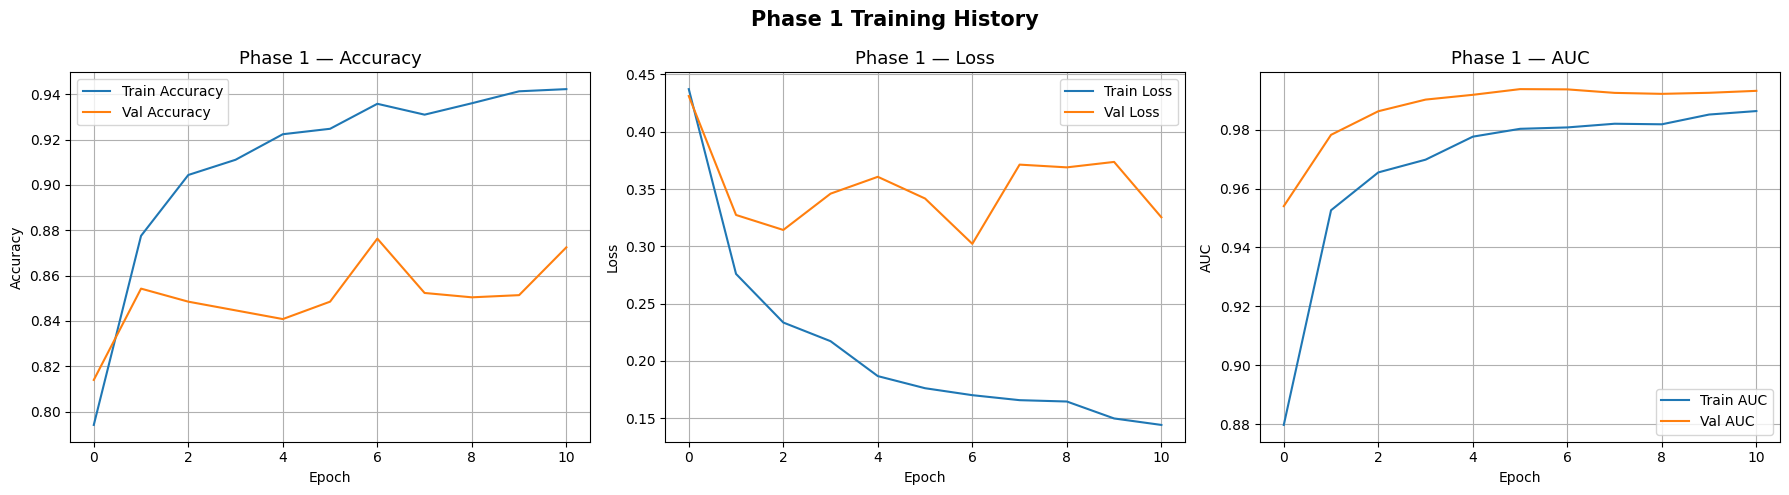

In [ ]:
# Phase 1 Training History — Accuracy, Loss & AUC Curves

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history_phase1.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_phase1.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Phase 1 — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_phase1.history['loss'],     label='Train Loss')
axes[1].plot(history_phase1.history['val_loss'], label='Val Loss')
axes[1].set_title('Phase 1 — Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# AUC
axes[2].plot(history_phase1.history['auc'],     label='Train AUC')
axes[2].plot(history_phase1.history['val_auc'], label='Val AUC')
axes[2].set_title('Phase 1 — AUC', fontsize=13)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Phase 1 Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phase1_training_history.png', dpi=150)
plt.show()

In [ ]:
#PHASE 2 - Fine Tuning the Model
# Unfreeze the top layers of DenseNet121 and train with a lower LR

# Unfreeze the base model
base_model.trainable = True

# Keep all layers frozen except the last 50
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers: {trainable_count}")

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# FIX: EarlyStopping monitors val_auc to match ModelCheckpoint
callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor             = 'val_auc',   # FIX: was val_loss
        patience            = 5,
        restore_best_weights= True,
        mode                = 'max',
        verbose             = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_auc',
        factor  = 0.5,
        patience= 3,
        mode    = 'max',
        verbose = 1,
        min_lr  = 1e-8
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath      = '/content/drive/MyDrive/densenet_phase2_best.keras',  # FIX: .keras
        monitor       = 'val_auc',
        save_best_only= True,
        mode          = 'max',
        verbose       = 1
    )
]

print("=" * 50)
print("PHASE 2: Fine Tuning")
print("=" * 50)

history_phase2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_phase2
)

Trainable layers: 50
PHASE 2: Fine Tuning
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - accuracy: 0.9311 - auc: 0.9780 - loss: 0.1863 - precision: 0.9738 - recall: 0.9323
Epoch 1: val_auc improved from None to 0.99368, saving model to /content/drive/MyDrive/densenet_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/densenet_phase2_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9312 - auc: 0.9788 - loss: 0.1816 - precision: 0.9750 - recall: 0.9313 - val_accuracy: 0.8447 - val_auc: 0.9937 - val_loss: 0.3612 - val_precision: 1.0000 - val_recall: 0.7910 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.9285 - auc: 0.9788 - loss: 0.1814 - precision: 0.9787 - recall: 0.9247
Epoch 2: val_auc did not improve from 0.99368
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 803ms/step - accuracy: 0.9324 - auc: 0.9785 - loss: 0.1809 - precision: 0.9802 - recall: 0.9277 - val_accuracy: 0.8533 - val_auc: 0.9934 - va

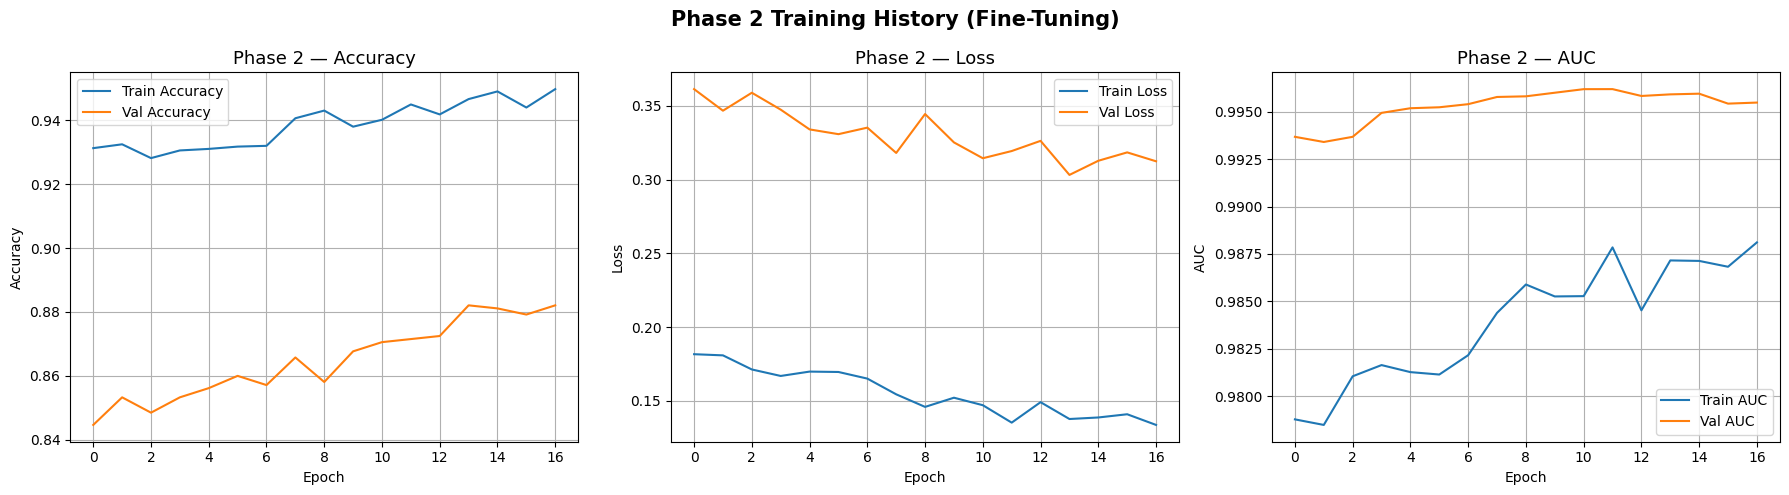

In [ ]:
# Phase 2 Training History — Accuracy, Loss & AUC Curves

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_phase2.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_phase2.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Phase 2 — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_phase2.history['loss'],     label='Train Loss')
axes[1].plot(history_phase2.history['val_loss'], label='Val Loss')
axes[1].set_title('Phase 2 — Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history_phase2.history['auc'],     label='Train AUC')
axes[2].plot(history_phase2.history['val_auc'], label='Val AUC')
axes[2].set_title('Phase 2 — AUC', fontsize=13)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Phase 2 Training History (Fine-Tuning)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phase2_training_history.png', dpi=150)
plt.show()

In [ ]:
# Load both saved models and compare — use the better one
print("Comparing Phase 1 vs Phase 2 results...")

model_phase1 = tf.keras.models.load_model(
    '/content/drive/MyDrive/densenet_phase1_best.keras'
)
model_phase1.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model_phase2 = tf.keras.models.load_model(
    '/content/drive/MyDrive/densenet_phase2_best.keras'
)
model_phase2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Evaluate both on validation set
print("\nPhase 1 best model:")
val_gen.reset()
r1 = model_phase1.evaluate(val_gen, verbose=0)
print(f"  Accuracy: {r1[1]*100:.2f}%")
print(f"  AUC:      {r1[2]:.4f}")
print(f"  Recall:   {r1[4]*100:.2f}%")

print("\nPhase 2 best model:")
val_gen.reset()
r2 = model_phase2.evaluate(val_gen, verbose=0)
print(f"  Accuracy: {r2[1]*100:.2f}%")
print(f"  AUC:      {r2[2]:.4f}")
print(f"  Recall:   {r2[4]*100:.2f}%")

# Select the better model based on AUC
if r1[2] >= r2[2]:
    best_model = model_phase1
    print("\nPhase 1 model is better — using densenet_phase1_best.keras")
else:
    best_model = model_phase2
    print("\nPhase 2 model is better — using densenet_phase2_best.keras")

# Save the definitive best model
best_model.save('/content/drive/MyDrive/densenet_BEST_FINAL.keras')
print("Best model saved as densenet_BEST_FINAL.keras")

Comparing Phase 1 vs Phase 2 results...

Phase 1 best model:
  Accuracy: 84.85%
  AUC:      0.9937
  Recall:   79.61%

Phase 2 best model:
  Accuracy: 87.15%
  AUC:      0.9962
  Recall:   82.71%

Phase 2 model is better — using densenet_phase2_best.keras
Best model saved as densenet_BEST_FINAL.keras


In [ ]:
# FIX: Use best_model already in memory instead of reloading from disk.
# The previous version redundantly loaded densenet_BEST_FINAL.h5 from
# disk even though best_model was already available in memory from Cell 10.

model = best_model

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print("Best model is ready.")

Best model is ready.


In [ ]:
# Validation Set Evaluation
val_gen.reset()
results = model.evaluate(val_gen, verbose=1)
print(f"\nAccuracy:  {results[1]*100:.2f}%")
print(f"AUC:       {results[2]:.4f}")
print(f"Precision: {results[3]*100:.2f}%")
print(f"Recall:    {results[4]*100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 643ms/step - accuracy: 0.8715 - auc: 0.9962 - loss: 0.3193 - precision: 1.0000 - recall: 0.8271

Accuracy:  87.15%
AUC:       0.9962
Precision: 100.00%
Recall:    82.71%


In [ ]:
#Reset test generator before evaluating
test_gen.reset()

print("=" * 50)
print("FINAL EVALUATION ON TEST SET")
print("=" * 50)

test_results = model.evaluate(test_gen, verbose=1)
print(f"\nTest Set Results")
print(f"\nLoss:      {test_results[0]:.4f}")
print(f"Accuracy:  {test_results[1]*100:.2f}%")   # FIX: was Auccuracy
print(f"AUC:       {test_results[2]:.4f}")
print(f"Precision: {test_results[3]*100:.2f}%")
print(f"Recall:    {test_results[4]*100:.2f}%")

FINAL EVALUATION ON TEST SET
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 901ms/step - accuracy: 0.9071 - auc: 0.9696 - loss: 0.2309 - precision: 0.9415 - recall: 0.9077

Test Set Results

Loss:      0.2309
Accuracy:  90.71%
AUC:       0.9696
Precision: 94.15%
Recall:    90.77%


20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 934ms/step


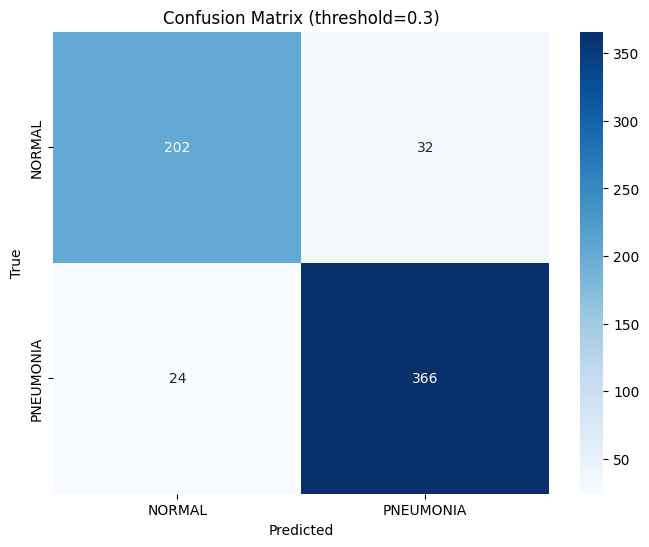


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.86      0.88       234
   PNEUMONIA       0.92      0.94      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624

True Negatives  — NORMAL correctly identified:     202
False Positives — NORMAL wrongly called PNEUMONIA: 32
False Negatives — PNEUMONIA missed:                24
True Positives  — PNEUMONIA correctly identified:  366


In [ ]:
#Confusion Matrix

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = (y_pred_probs > FINAL_THRESHOLD).astype(int).flatten()
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot        = True,
    fmt          = 'd',
    cmap         = 'Blues',
    xticklabels  = CLASS_NAMES,
    yticklabels  = CLASS_NAMES
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (threshold={FINAL_THRESHOLD})')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  — NORMAL correctly identified:     {tn}")
print(f"False Positives — NORMAL wrongly called PNEUMONIA: {fp}")
print(f"False Negatives — PNEUMONIA missed:                {fn}")
print(f"True Positives  — PNEUMONIA correctly identified:  {tp}")

In [ ]:
# Threshold Tuning on VALIDATION SET
# FIX: Threshold selection must be done on the validation set, NOT the
# test set. Using the test set for threshold selection is data leakage —
# it makes the chosen threshold falsely optimistic on the test results.
# The test set is used ONLY for final evaluation in the next cell.

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

best_f1        = -1
best_threshold = 0.0

print(f"{'Threshold':<12}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}"
      f"{'F1':<10}{'Specificity':<14}{'FN':<8}{'FP':<8}")
print("-" * 86)

val_gen.reset()
y_pred_probs_val = model.predict(val_gen, verbose=0)
y_true_val = val_gen.classes

for thresh in thresholds:
    y_pred_t = (y_pred_probs_val > thresh).astype(int).flatten()

    tn, fp, fn, tp = confusion_matrix(y_true_val, y_pred_t).ravel()

    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp)   if (tp + fp) > 0 else 0
    recall      = tp / (tp + fn)   if (tp + fn) > 0 else 0
    f1          = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp)   if (tn + fp) > 0 else 0  # NEW column

    print(f"{thresh:<12}{accuracy*100:<12.2f}{precision*100:<12.2f}{recall*100:<12.2f}"
          f"{f1*100:<10.2f}{specificity*100:<14.2f}{fn:<8}{fp:<8}")

    if f1 > best_f1:
        best_f1        = f1
        best_threshold = thresh

print(f"\nBest threshold (on val set): {best_threshold}  |  F1: {best_f1*100:.2f}%")

Threshold   Accuracy    Precision   Recall      F1        Specificity   FN      FP      
--------------------------------------------------------------------------------------
0.3         90.89       100.00      87.74       93.47     100.00        95      0       
0.35        90.41       100.00      87.10       93.10     100.00        100     0       
0.4         89.26       100.00      85.55       92.21     100.00        112     0       
0.45        88.40       100.00      84.39       91.53     100.00        121     0       
0.5         87.15       100.00      82.71       90.54     100.00        134     0       
0.55        86.19       100.00      81.42       89.76     100.00        144     0       
0.6         85.33       100.00      80.26       89.05     100.00        153     0       
0.65        83.70       100.00      78.06       87.68     100.00        170     0       
0.7         83.03       100.00      77.16       87.11     100.00        177     0       

Best threshold (on val

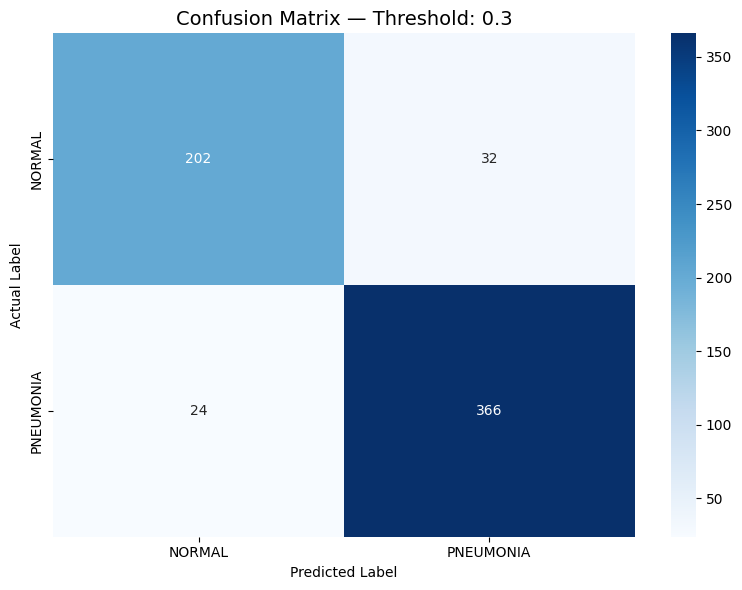


Final Classification Report (threshold=0.3)
              precision    recall  f1-score   support

      NORMAL       0.89      0.86      0.88       234
   PNEUMONIA       0.92      0.94      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624

True Negatives  — NORMAL Case correctly identified:     202
False Positives — NORMAL Case wrongly called PNEUMONIA: 32
False Negatives — PNEUMONIA Case missed:                24
True Positives  — PNEUMONIA Case correctly identified:  366


In [ ]:
# Apply Best Threshold to TEST SET for final evaluation

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=0)
y_true       = test_gen.classes

y_pred_best = (y_pred_probs > best_threshold).astype(int).flatten()
cm_best     = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_best,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES
)
plt.title(f'Confusion Matrix — Threshold: {best_threshold}', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nFinal Classification Report (threshold={best_threshold})")  # FIX: was threshold=:
print(classification_report(y_true, y_pred_best, target_names=CLASS_NAMES))

tn, fp, fn, tp = cm_best.ravel()
print(f"True Negatives  — NORMAL Case correctly identified:     {tn}")
print(f"False Positives — NORMAL Case wrongly called PNEUMONIA: {fp}")
print(f"False Negatives — PNEUMONIA Case missed:                {fn}")
print(f"True Positives  — PNEUMONIA Case correctly identified:  {tp}")

EXTENDED METRICS (best threshold on test set)
Specificity (True Negative Rate): 86.32%
Negative Predictive Value (NPV):  89.38%
Matthews Correlation Coeff (MCC): 0.8075
AUC (sklearn, from probs):        0.9702


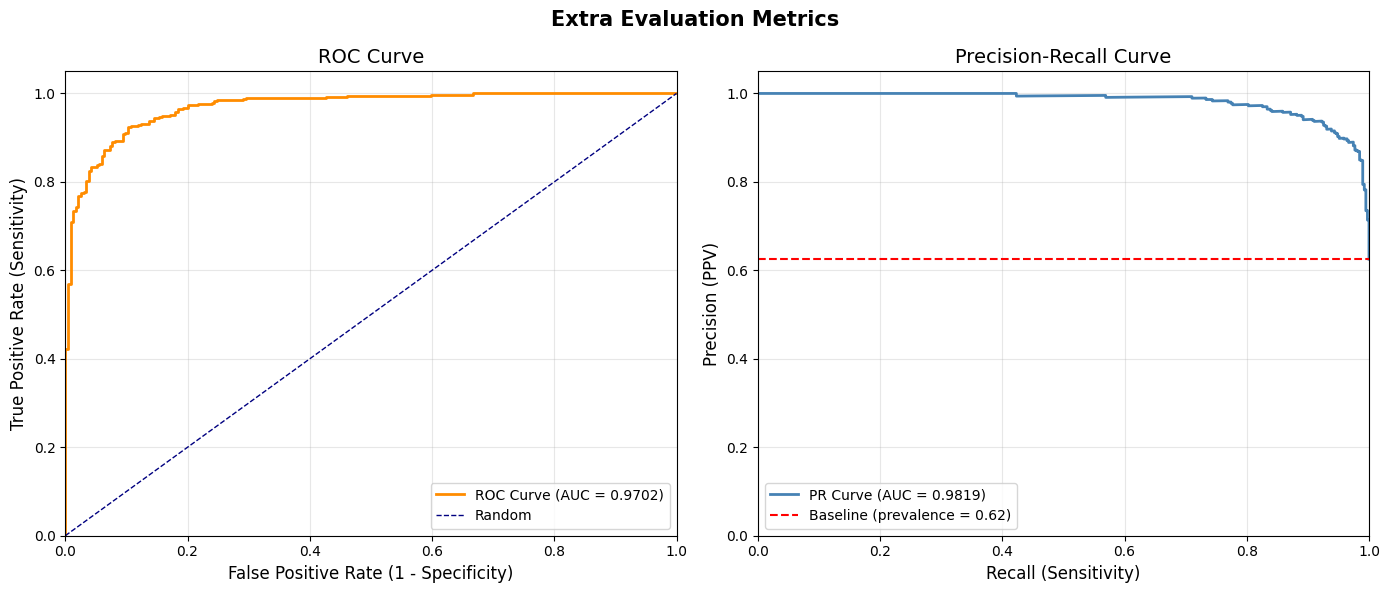

In [ ]:
# ── EXTRA METRICS ──────────────────────────────────────────────────────────
# ROC Curve, Precision-Recall Curve, Specificity, NPV, MCC, sklearn AUC
# y_true and y_pred_probs were set in the previous cell

tn, fp, fn, tp = cm_best.ravel()

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv         = tn / (tn + fn) if (tn + fn) > 0 else 0   # Negative Predictive Value
mcc         = matthews_corrcoef(y_true, y_pred_best)     # Matthews Correlation Coefficient
sklearn_auc = auc(*roc_curve(y_true, y_pred_probs)[:2])  # Area under ROC

print("=" * 50)
print("EXTENDED METRICS (best threshold on test set)")
print("=" * 50)
print(f"Specificity (True Negative Rate): {specificity*100:.2f}%")
print(f"Negative Predictive Value (NPV):  {npv*100:.2f}%")
print(f"Matthews Correlation Coeff (MCC): {mcc:.4f}")
print(f"AUC (sklearn, from probs):        {sklearn_auc:.4f}")

# ── ROC CURVE ─────────────────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# ── PRECISION-RECALL CURVE ────────────────────────────────────────────────────
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall_vals, precision_vals)

axes[1].plot(recall_vals, precision_vals, color='steelblue', lw=2,
             label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].axhline(y=sum(y_true)/len(y_true), color='red', linestyle='--',
                label=f'Baseline (prevalence = {sum(y_true)/len(y_true):.2f})')
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision (PPV)', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Extra Evaluation Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/extra_metrics.png', dpi=150)
plt.show()

In [ ]:
# Build the model graph by running one dummy prediction
dummy_input = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = model(dummy_input, training=False)
print("Model graph built successfully")
print(f"Model input shape:  {model.input_shape}")
print(f"Model output shape: {model.output_shape}")

Model graph built successfully
Model input shape:  (None, 224, 224, 3)
Model output shape: (None, 1)


Running CAM on PNEUMONIA sample...


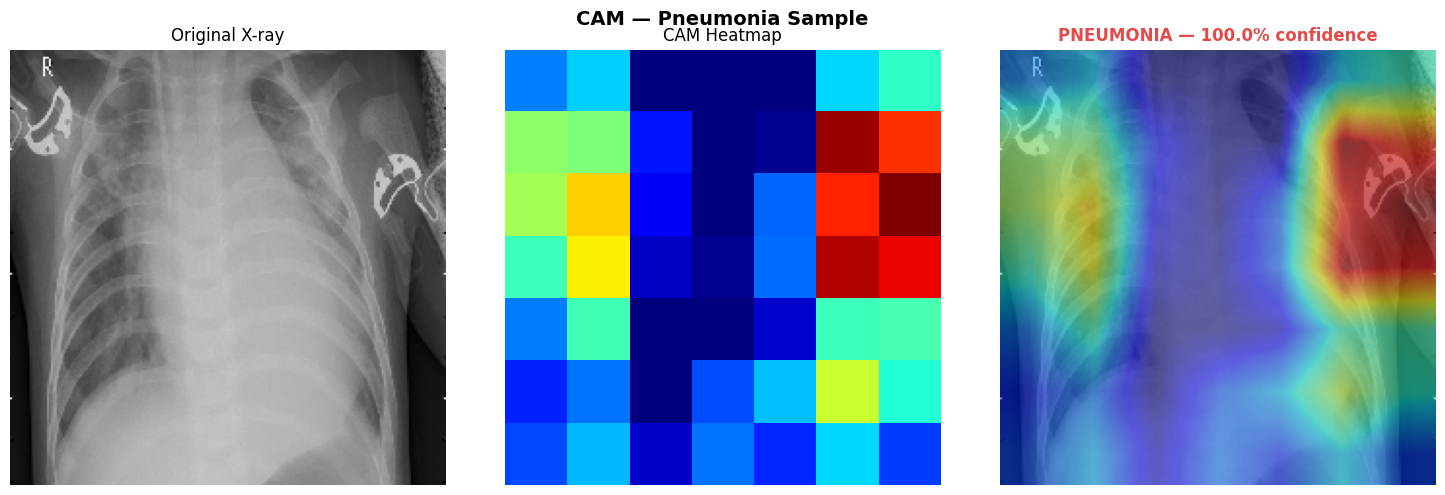

Prediction: PNEUMONIA (100.0%)

Running CAM on NORMAL sample...


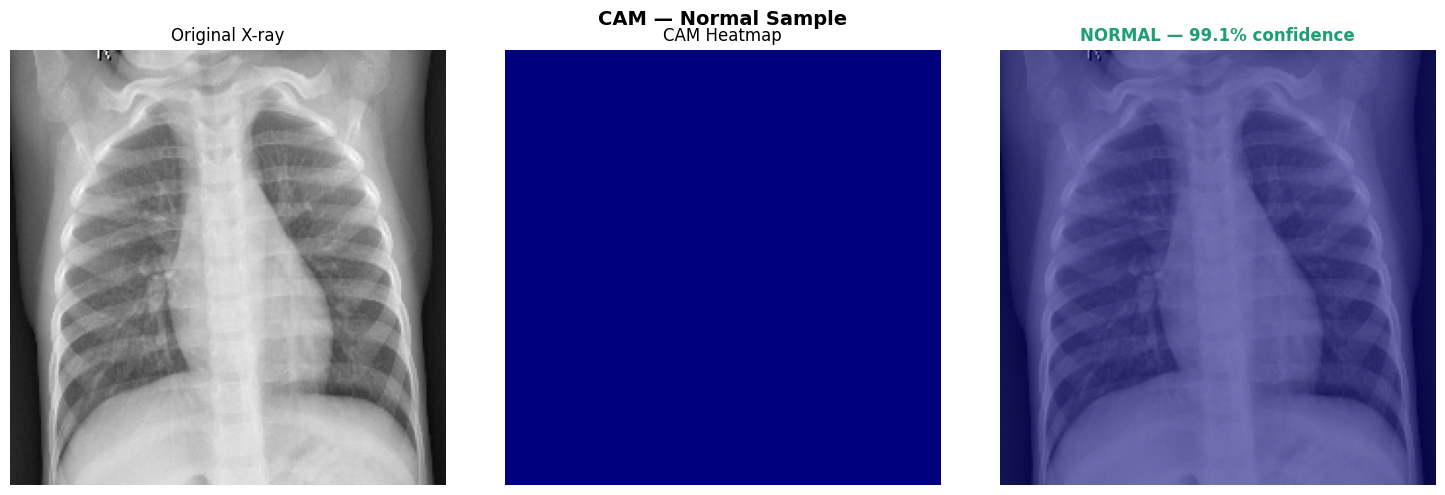

Prediction: NORMAL (99.1%)


In [ ]:
import matplotlib.cm as mpl_cm
from tensorflow.keras.preprocessing import image as keras_image

def make_cam_heatmap(img_array, model):
    """
    CAM approach — weighted combination of DenseNet121 feature maps.
    Multiplies Dense weight matrices to get a (1024,) importance vector
    that maps conv features directly to the final sigmoid output.
    """
    base_model = model.layers[0]  # DenseNet121

    feature_model = tf.keras.models.Model(
        inputs  = base_model.input,
        outputs = base_model.output
    )

    img_tensor  = tf.cast(img_array, tf.float32)
    feature_maps= feature_model(img_tensor, training=False)
    feature_maps= feature_maps[0]   # (7, 7, 1024)

    pred        = model(img_tensor, training=False)
    pred_value  = float(pred[0][0])

    # Dense layer weights (after GAP)
    # layers[1]=GAP, [2]=BatchNorm, [3]=Dense(256), [4]=Dropout,
    # [5]=Dense(128), [6]=Dropout, [7]=Dense(1)
    W1 = model.layers[3].get_weights()[0]  # (1024, 256)
    W2 = model.layers[5].get_weights()[0]  # (256,  128)
    W3 = model.layers[7].get_weights()[0]  # (128,    1)

    combined = W1 @ W2 @ W3   # (1024, 1)
    combined = combined.squeeze()

    heatmap = np.tensordot(feature_maps.numpy(), combined, axes=([2], [0]))  # (7, 7)
    heatmap = np.maximum(heatmap, 0)
    max_val = np.max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap, pred_value


def display_cam(img_path, model, title=""):
    img       = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_norm  = np.expand_dims(img_array, axis=0) / 255.0

    heatmap, pred = make_cam_heatmap(img_norm, model)

    label       = 'PNEUMONIA' if pred >= FINAL_THRESHOLD else 'NORMAL'
    confidence  = pred * 100 if pred >= FINAL_THRESHOLD else (1 - pred) * 100
    label_color = '#E24B4A' if label == 'PNEUMONIA' else '#1D9E75'

    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_4d    = heatmap_uint8[..., np.newaxis]
    heatmap_large = tf.image.resize(heatmap_4d, (224, 224)).numpy().squeeze()

    heatmap_colored = mpl_cm.jet(heatmap_large / 255.0)[:, :, :3]
    original        = img_array / 255.0
    superimposed    = np.clip(heatmap_colored * 0.5 + original * 0.5, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.patch.set_facecolor('white')

    axes[0].imshow(original)
    axes[0].set_title('Original X-ray', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('CAM Heatmap', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(
        f'{label} — {confidence:.1f}% confidence',
        fontsize=12, color=label_color, fontweight='bold'
    )
    axes[2].axis('off')

    plt.suptitle(f'CAM — {title}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/cam_{title.replace(" ", "_")}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"Prediction: {label} ({confidence:.1f}%)")


# Test on one PNEUMONIA and one NORMAL image
pneumonia_img = os.path.join(
    test_dir, 'PNEUMONIA',
    os.listdir(os.path.join(test_dir, 'PNEUMONIA'))[0]
)
normal_img = os.path.join(
    test_dir, 'NORMAL',
    os.listdir(os.path.join(test_dir, 'NORMAL'))[0]
)

print("Running CAM on PNEUMONIA sample...")
display_cam(pneumonia_img, model, title='Pneumonia Sample')

print("\nRunning CAM on NORMAL sample...")
display_cam(normal_img, model, title='Normal Sample')

In [ ]:
# ── TFLITE CONVERSION ─────────────────────────────────────────────────────
# FIX 1: tflite_path now correctly uses a .tflite extension.
#         The original code set tflite_path = 'densenet_BEST_FINAL.h5',
#         which overwrote and permanently corrupted the Keras model file
#         with raw TFLite binary data.
# FIX 2: size_mb calculation and print statements moved OUTSIDE the
#         with open() block (they were incorrectly indented inside it).

print("Converting model to TFLite for mobile deployment...")
converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = '/content/drive/MyDrive/densenet_pneumonia.tflite'  # FIX
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# FIX: These lines now run AFTER the file is closed, outside the with block
size_mb = len(tflite_model) / (1024 * 1024)
print(f"TFLite model saved successfully")
print(f"Model Size: {size_mb:.2f} MB")
print(f"Saved to:   {tflite_path}")

Converting model to TFLite for mobile deployment...
Saved artifact at '/tmp/tmpb9bzccbk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135822548736080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548739344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548734160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548734928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548740496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548741648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548735504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548740880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548741264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548737040: TensorSpec(sha

In [ ]:
# ── VERIFICATION OF TFLITE ACCURACY ─────────────────────────────────────────

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

test_gen.reset()
tflite_preds = []

for i in range(test_gen.samples):
    img = test_gen[i // BATCH_SIZE][0][i % BATCH_SIZE]
    img = np.expand_dims(img, axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    tflite_preds.append(output_data[0][0])

tflite_preds    = np.array(tflite_preds)
y_true_tflite   = test_gen.classes
y_pred_tflite   = (tflite_preds > FINAL_THRESHOLD).astype(int)

tflite_accuracy = np.mean(y_pred_tflite == y_true_tflite) * 100
print(f"TFLite Model Accuracy: {tflite_accuracy:.2f}%")
print(f"Keras  Model Accuracy: {test_results[1]*100:.2f}%")   # FIX: was Accuacy
print(f"Accuracy difference:   {abs(tflite_accuracy - test_results[1]*100):.2f}%")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite Model Accuracy: 91.03%
Keras  Model Accuracy: 90.71%
Accuracy difference:   0.32%


In [ ]:
# ── TFLITE FILE DOWNLOAD ─────────────────────────────────────────────────────
# FIX: Use tflite_path variable instead of a hardcoded string so this cell
#      always downloads the file that was actually saved in Cell 19.

from google.colab import files
files.download(tflite_path)
print(f"Downloaded: {tflite_path}")
print("Check your browser Downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/drive/MyDrive/densenet_pneumonia.tflite
Check your browser Downloads folder.


In [ ]:
import tensorflow as tf
from tensorflow import keras
import keras.ops as ops
import numpy as np

# 1. Find the DenseNet base
base_model = None
for layer in model.layers:
    if isinstance(layer, keras.Model) or layer.name.startswith("densenet"):
        base_model = layer
        break

last_conv_layer = base_model.get_layer("conv5_block16_concat")

new_input = keras.Input(shape=(224, 224, 3))
final_score = model(new_input)

# Get raw feature maps and Global Average Pooling
feature_maps = keras.Model(inputs=base_model.input, outputs=last_conv_layer.output)(new_input)
x = keras.layers.GlobalAveragePooling2D()(feature_maps)

# 2. Extract classification head layers
head_layers = model.layers[model.layers.index(base_model)+1:]

activations = [x]
masks = []
layers_to_backprop = []

# Forward pass: Build the graph dynamically using keras.ops
for layer in head_layers:
    if isinstance(layer, keras.layers.GlobalAveragePooling2D):
        continue
    elif isinstance(layer, keras.layers.Dense):
        W, b = layer.get_weights()

        # Mathematical operations directly on KerasTensors using ops
        h = ops.matmul(activations[-1], W) + b

        # Robust check for activation type
        activation_name = keras.activations.serialize(layer.activation)
        if activation_name == 'relu':
            mask = ops.cast(h > 0, dtype="float32")
            masks.append(mask)
            activations.append(h * mask)
            layers_to_backprop.append({'type': 'dense_relu', 'W': W, 'mask_idx': len(masks)-1})
        else:
            activations.append(h)
            layers_to_backprop.append({'type': 'dense_linear', 'W': W})

    elif isinstance(layer, keras.layers.BatchNormalization):
        gamma, beta, moving_mean, moving_variance = layer.get_weights()
        scale = gamma / np.sqrt(moving_variance + layer.epsilon)

        bn_out = (activations[-1] - moving_mean) * scale + beta
        activations.append(bn_out)
        layers_to_backprop.append({'type': 'bn', 'scale': scale})

    elif isinstance(layer, keras.layers.Dropout):
        activations.append(activations[-1])
        layers_to_backprop.append({'type': 'dropout'})

# 3. Backward pass: Match output batch size dynamically
grad = ops.ones_like(final_score)

for op in reversed(layers_to_backprop):
    if op['type'] == 'dropout':
        continue
    elif op['type'] == 'bn':
        grad = grad * op['scale']
    elif op['type'] == 'dense_linear':
        grad = ops.matmul(grad, op['W'].T)
    elif op['type'] == 'dense_relu':
        mask = masks[op['mask_idx']]
        grad = ops.matmul(grad * mask, op['W'].T)

# 4. Generate the Heatmap
num_channels = feature_maps.shape[-1] # Dynamically get channels (e.g., 1024)
grad_x_reshaped = ops.reshape(grad, (-1, 1, 1, num_channels))
heatmap = ops.sum(feature_maps * grad_x_reshaped, axis=-1, keepdims=True)

smart_multi_output_model = keras.Model(
    inputs=new_input,
    outputs=[final_score, heatmap]
)

# 5. Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(smart_multi_output_model)
tflite_smart = converter.convert()
#save
smart_path = '/content/drive/MyDrive/MULTI_OUTPUT_MODEL_flutter.tflite'
with open(smart_path, 'wb') as f:
    f.write(tflite_smart)

print("Model Saved!")

Saved artifact at '/tmp/tmp5omw886p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_2464')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7, 7, 1), dtype=tf.float32, name=None)]
Captures:
  135822548736080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548739344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548734160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548734928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548740496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548741648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548735504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548740880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548741264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135822548